# Spectral Bridge Notebook


In [2]:
import os
import random
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Callable, Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

TQDM_DISABLED = os.environ.get("TQDM_DISABLE", "0") == "1"


/Users/aman/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1) Config


In [3]:
@dataclass
class BridgeRunConfig:
    train_csv: Path = Path("train.csv")
    test_csv_candidates: Tuple[str, ...] = (
        "test.csv",
        "Test.csv",
        "round1_test.csv",
        "test_data/test.csv",
        "test_data/Test.csv",
        "test_data/round1_test.csv",
    )
    submission_path: Path = Path("submission.csv")
    summary_path: Path = Path("run_summary.csv")
    artifact_dir: Path = Path("artifacts")

    seed: int = 42
    val_size: float = 0.10
    n_eda_samples: int = 5
    n_val_plots: int = 10
    n_test_plots: int = 10


CFG = BridgeRunConfig()
print(f"Config: val_size={CFG.val_size}, artifact_dir={CFG.artifact_dir}")


Config: val_size=0.1, artifact_dir=artifacts


## 2) Utils


In [4]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


def ensure_artifact_dir(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path


def finalize_figure(fig: plt.Figure, filename: str, cfg: BridgeRunConfig) -> None:
    out_dir = ensure_artifact_dir(cfg.artifact_dir)
    out_path = out_dir / filename
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    backend = plt.get_backend().lower()
    if "agg" not in backend:
        plt.show()
    plt.close(fig)
    print(f"Saved figure: {out_path.resolve()}")


def mse_from_arrays(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean((y_true - y_pred) ** 2))


## 3) Data


In [5]:
def load_dataframe(csv_path: Path, is_train: bool = True) -> pd.DataFrame:
    if not csv_path.exists():
        raise FileNotFoundError(f"CSV not found: {csv_path.resolve()}")

    dtype_map = {
        "Sample_ID": np.int32,
        "Time_ms": np.float32,
        "Is_Context": np.int8,
    }
    df = pd.read_csv(csv_path, dtype=dtype_map, low_memory=False)

    required = {"Sample_ID", "Time_ms", "Is_Context"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{csv_path.name} is missing columns: {sorted(missing)}")

    if "Value" in df.columns:
        df["Value"] = pd.to_numeric(df["Value"], errors="coerce").astype(np.float32)
    elif is_train:
        raise ValueError(f"{csv_path.name} must contain a Value column for training data.")

    df = df.sort_values(["Sample_ID", "Time_ms"], kind="mergesort").reset_index(drop=True)
    return df


def eda_report(df: pd.DataFrame, title: str = "Train Data") -> None:
    print(f"\n{'=' * 50}")
    print(f"  {title}")
    print(f"{'=' * 50}")
    print(f"Shape:              {df.shape[0]:,} rows x {df.shape[1]} cols")
    print(f"Unique samples:     {df['Sample_ID'].nunique():,}")
    print(f"Null values:        {df.isnull().sum().sum()}")
    print("\nColumn dtypes:")
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            cmin = df[col].min(skipna=True)
            cmax = df[col].max(skipna=True)
            print(f"  {col:15s}  {str(df[col].dtype):10s}  range=[{cmin:.4f}, {cmax:.4f}]")
        else:
            print(f"  {col:15s}  {str(df[col].dtype):10s}")

    per_sample = (
        df.groupby("Sample_ID")["Is_Context"]
        .agg(
            context_pts=lambda s: int((s == 1).sum()),
            target_pts=lambda s: int((s == 0).sum()),
        )
    )
    print(f"\nPoints per sample (averaged over {len(per_sample):,} samples):")
    print(f"  Context:  {per_sample['context_pts'].mean():.1f}")
    print(f"  Target:   {per_sample['target_pts'].mean():.1f}")
    print(f"  Total:    {(per_sample['context_pts'] + per_sample['target_pts']).mean():.1f}")


def plot_random_samples(df: pd.DataFrame, cfg: BridgeRunConfig) -> None:
    unique_ids = df["Sample_ID"].unique()
    n_samples = min(cfg.n_eda_samples, len(unique_ids))
    rng = np.random.default_rng(cfg.seed)
    chosen_ids = rng.choice(unique_ids, size=n_samples, replace=False)

    fig, axes = plt.subplots(n_samples, 1, figsize=(12, 3.0 * n_samples), squeeze=False)

    for ax, sid in zip(axes.ravel(), chosen_ids):
        sdf = df[df["Sample_ID"] == sid].sort_values("Time_ms")
        ax.plot(sdf["Time_ms"], sdf["Value"], color="gray", alpha=0.30, lw=1, label="Full waveform")

        ctx = sdf[sdf["Is_Context"] == 1]
        tgt = sdf[sdf["Is_Context"] == 0]
        ax.scatter(ctx["Time_ms"], ctx["Value"], s=14, color="royalblue", zorder=3, label="Context")
        ax.scatter(tgt["Time_ms"], tgt["Value"], s=18, color="crimson", zorder=3, label="Target")
        ax.set_title(f"Sample {int(sid)}", fontsize=10)
        ax.set_xlabel("Time (ms)")
        ax.set_ylabel("Voltage")
        ax.grid(alpha=0.15)

    handles, labels = axes.ravel()[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=9)
    fig.suptitle("Random training samples", fontsize=11, y=1.01)
    fig.tight_layout()
    finalize_figure(fig, "eda_random_samples.png", cfg)


## 4) Records


In [6]:
def build_sample_records(df: pd.DataFrame) -> List[Dict[str, np.ndarray]]:
    records: List[Dict[str, np.ndarray]] = []

    grouped = df.groupby("Sample_ID", sort=True, observed=True)
    for sample_id, sdf in tqdm(
        grouped,
        total=df["Sample_ID"].nunique(),
        desc="Building sample records",
        disable=TQDM_DISABLED,
    ):
        time_raw = sdf["Time_ms"].to_numpy(dtype=np.float32, copy=True)
        is_context = sdf["Is_Context"].to_numpy(dtype=np.int8, copy=True) == 1

        if "Value" in sdf.columns:
            y = sdf["Value"].to_numpy(dtype=np.float32, copy=True)
        else:
            y = np.full_like(time_raw, np.nan, dtype=np.float32)

        records.append(
            {
                "sample_id": np.int32(sample_id),
                "time_raw": time_raw,
                "y": y,
                "is_context": is_context,
            }
        )

    return records


def split_records(records: Sequence[Dict[str, np.ndarray]], cfg: BridgeRunConfig):
    sample_ids = [int(r["sample_id"]) for r in records]
    train_ids, val_ids = train_test_split(
        sample_ids,
        test_size=cfg.val_size,
        random_state=cfg.seed,
        shuffle=True,
    )
    train_set = set(train_ids)
    val_set = set(val_ids)

    train_records = [r for r in records if int(r["sample_id"]) in train_set]
    val_records = [r for r in records if int(r["sample_id"]) in val_set]
    return train_records, val_records


## 5) Reconstruction


In [7]:
def context_mean_predict(time_context: np.ndarray, y_context: np.ndarray, time_target: np.ndarray) -> np.ndarray:
    del time_context
    return np.full(time_target.shape, np.mean(y_context), dtype=np.float32)


def linear_interp_predict(time_context: np.ndarray, y_context: np.ndarray, time_target: np.ndarray) -> np.ndarray:
    pred = np.interp(time_target, time_context, y_context)
    return np.asarray(pred, dtype=np.float32)


def _linear_extrapolate(x0: float, y0: float, x1: float, y1: float, x: np.ndarray) -> np.ndarray:
    slope = (y1 - y0) / (x1 - x0)
    return y0 + slope * (x - x0)


def edge_aware_cubic_predict(time_context: np.ndarray, y_context: np.ndarray, time_target: np.ndarray) -> np.ndarray:
    if len(time_context) < 4:
        return linear_interp_predict(time_context, y_context, time_target)

    spline = CubicSpline(time_context, y_context, bc_type="natural", extrapolate=False)
    pred = np.asarray(spline(time_target), dtype=np.float32)

    left = time_target < time_context[0]
    right = time_target > time_context[-1]

    if left.any():
        pred[left] = _linear_extrapolate(
            time_context[0], y_context[0], time_context[1], y_context[1], time_target[left]
        )
    if right.any():
        pred[right] = _linear_extrapolate(
            time_context[-1], y_context[-1], time_context[-2], y_context[-2], time_target[right]
        )

    return np.asarray(pred, dtype=np.float32)


def predict_one_record(
    record: Dict[str, np.ndarray],
    predictor: Callable[[np.ndarray, np.ndarray, np.ndarray], np.ndarray],
) -> Dict[str, np.ndarray]:
    is_ctx = record["is_context"].copy()

    if is_ctx.sum() == 0:
        is_ctx[0] = True
    if is_ctx.all():
        is_ctx[-1] = False

    ctx_idx = np.where(is_ctx)[0]
    tgt_idx = np.where(~is_ctx)[0]

    time_context = record["time_raw"][ctx_idx]
    y_context = record["y"][ctx_idx]
    time_target = record["time_raw"][tgt_idx]
    y_true = record["y"][tgt_idx]
    y_pred = predictor(time_context, y_context, time_target)

    return {
        "sample_id": int(record["sample_id"]),
        "time_context": time_context,
        "y_context": y_context,
        "time_target": time_target,
        "y_true": y_true,
        "y_pred": y_pred,
    }


def evaluate_predictor(
    records: Sequence[Dict[str, np.ndarray]],
    predictor: Callable[[np.ndarray, np.ndarray, np.ndarray], np.ndarray],
    desc: str,
) -> float:
    total_sse = 0.0
    total_n = 0

    for record in tqdm(records, desc=desc, disable=TQDM_DISABLED):
        out = predict_one_record(record, predictor)
        valid = np.isfinite(out["y_true"])
        if not valid.any():
            continue
        err = out["y_pred"][valid] - out["y_true"][valid]
        total_sse += float(np.square(err).sum())
        total_n += int(valid.sum())

    return total_sse / max(total_n, 1)


def benchmark_predictors(val_records: Sequence[Dict[str, np.ndarray]]) -> pd.DataFrame:
    rows = []
    methods = {
        "context_mean": context_mean_predict,
        "linear_interp": linear_interp_predict,
        "edge_aware_cubic_spline": edge_aware_cubic_predict,
    }

    for name, predictor in methods.items():
        mse = evaluate_predictor(val_records, predictor, desc=f"Validating {name}")
        rows.append({"method": name, "val_mse": float(mse)})

    return pd.DataFrame(rows).sort_values("val_mse", kind="mergesort").reset_index(drop=True)


## 6) Plots


In [8]:
def plot_holdout_samples(
    records: Sequence[Dict[str, np.ndarray]],
    predictor: Callable[[np.ndarray, np.ndarray, np.ndarray], np.ndarray],
    filename: str,
    title: str,
    cfg: BridgeRunConfig,
    show_truth: bool,
    n: int,
    seed: int,
) -> None:
    n = min(n, len(records))
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(records), size=n, replace=False)

    fig, axes = plt.subplots(n, 1, figsize=(13, 3.0 * n), squeeze=False)

    for ax, i in zip(axes.ravel(), idx):
        out = predict_one_record(records[i], predictor)
        order = np.argsort(out["time_target"])

        ax.scatter(out["time_context"], out["y_context"], s=16, c="royalblue", label="Context", zorder=3)
        if show_truth:
            ax.scatter(
                out["time_target"],
                out["y_true"],
                s=18,
                c="crimson",
                alpha=0.7,
                label="True target",
                zorder=3,
            )
        ax.plot(
            out["time_target"][order],
            out["y_pred"][order],
            c="green",
            lw=2,
            label="Predicted",
            zorder=2,
        )
        ax.scatter(out["time_target"][order], out["y_pred"][order], s=12, c="green", zorder=2)
        ax.set_title(f"Sample {out['sample_id']}", fontsize=10)
        ax.set_xlabel("Time (ms)")
        ax.set_ylabel("Voltage")
        ax.grid(alpha=0.15)

    handles, labels = axes.ravel()[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=9)
    fig.suptitle(title, fontsize=11, y=1.01)
    fig.tight_layout()
    finalize_figure(fig, filename, cfg)


## 7) Inference


In [9]:
def find_test_csv(candidates: Sequence[str]) -> Optional[Path]:
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    return None


def run_inference(
    records: Sequence[Dict[str, np.ndarray]],
    predictor: Callable[[np.ndarray, np.ndarray, np.ndarray], np.ndarray],
) -> pd.DataFrame:
    rows_sid: List[int] = []
    rows_time: List[float] = []
    rows_pred: List[float] = []

    for record in tqdm(records, desc="Inference", disable=TQDM_DISABLED):
        out = predict_one_record(record, predictor)
        rows_sid.extend([out["sample_id"]] * len(out["time_target"]))
        rows_time.extend(out["time_target"].tolist())
        rows_pred.extend(out["y_pred"].tolist())

    return (
        pd.DataFrame(
            {
                "Sample_ID": np.array(rows_sid, dtype=np.int32),
                "Time_ms": np.array(rows_time, dtype=np.float32),
                "Predicted_Value": np.array(rows_pred, dtype=np.float32),
            }
        )
        .sort_values(["Sample_ID", "Time_ms"], kind="mergesort")
        .reset_index(drop=True)
    )


## 8) Train Then Test


Preparing val features: 100%|██████████| 8000/8000 [00:00<00:00, 11837.62it/s]


Run started: 2026-03-15 17:28:20
Device: mps
Model: ResidualSplineNet
Parameters: 162,753
Train samples: 72,000
Val samples:   8,000
Batch size:    128
Epochs:        30
Early stopping: off
Learning rate: 0.002
Weight decay:  0.0001
Accuracy tol:  +/-0.050
Spline baseline | MSE 0.003892 | MAE 0.037047 | Acc@0.05 77.15%
Epoch 001/30 | Train MSE 0.003684 | Val MSE 0.002132 | Train Acc@0.05 80.91% | Val Acc@0.05 84.45% | Spline MSE 0.003892 | Gap -0.001760 | LR 1.99e-03 | GradNorm 0.0261 | Time 22.4s
  >> saved best checkpoint at epoch 1 with val MSE 0.002132
Epoch 002/30 | Train MSE 0.002146 | Val MSE 0.002101 | Train Acc@0.05 84.46% | Val Acc@0.05 84.76% | Spline MSE 0.003892 | Gap -0.001791 | LR 1.98e-03 | GradNorm 0.0052 | Time 22.5s
  >> saved best checkpoint at epoch 2 with val MSE 0.002101
Epoch 003/30 | Train MSE 0.002098 | Val MSE 0.002061 | Train Acc@0.05 84.76% | Val Acc@0.05 84.88% | Spline MSE 0.003892 | Gap -0.001831 | LR 1.95e-03 | GradNorm 0.0050 | Time 21.8s
  >> saved be

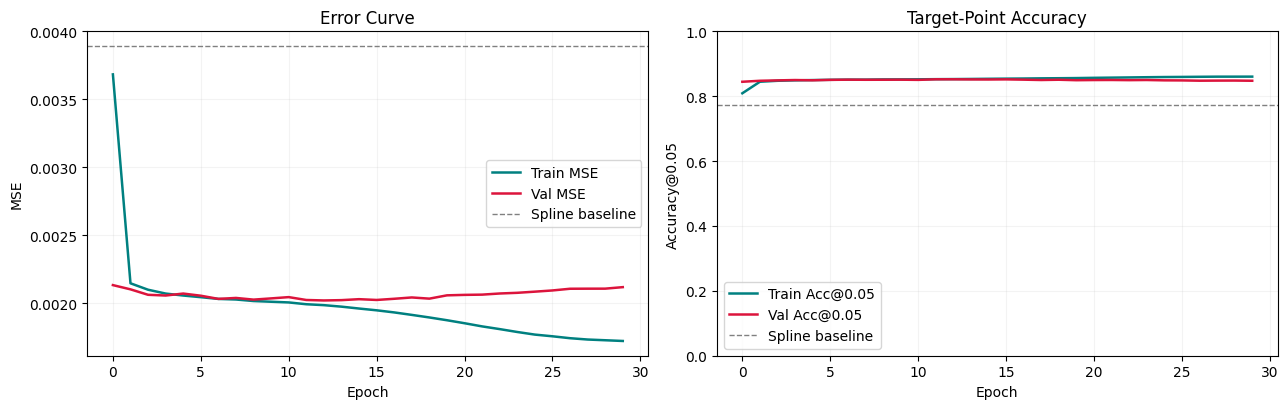

Saved figure: /Users/aman/Desktop/Spectral Bridge/artifacts/residual_training_curve.png


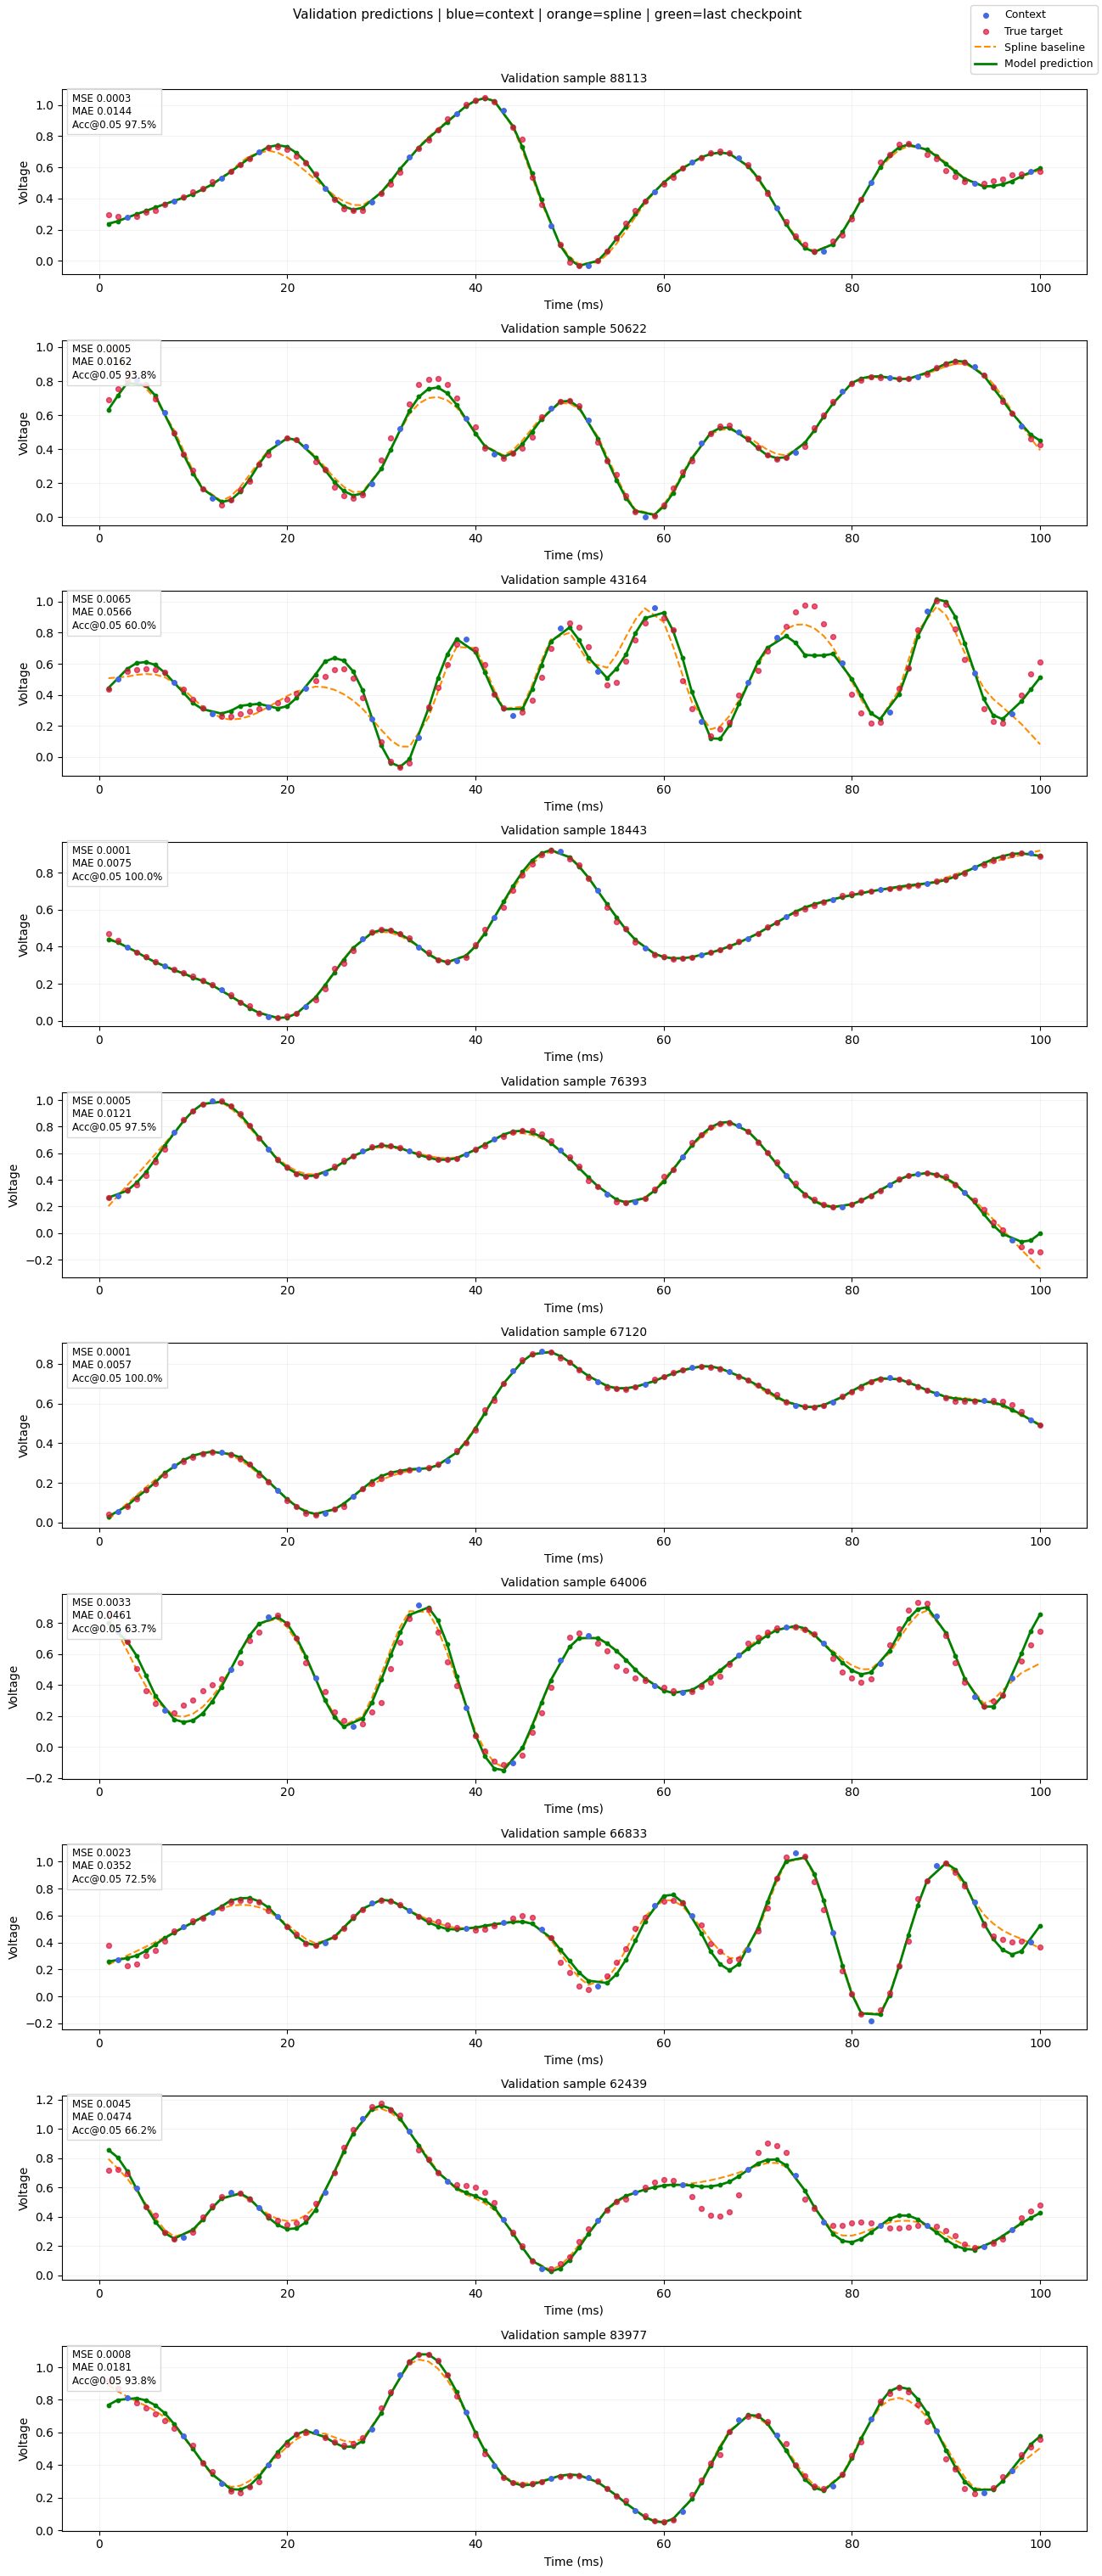

Saved figure: /Users/aman/Desktop/Spectral Bridge/artifacts/val_predictions_recent_model.png

Training complete.
Last checkpoint epoch:     30
Last val MSE:              0.002117
Last val MAE:              0.027701
Last val Acc@0.05:        84.76%
Best checkpoint epoch:     13
Best checkpoint val MSE:   0.002019
Last checkpoint path:      /Users/aman/Desktop/Spectral Bridge/last_residual_spline_net.pt
Best checkpoint path:      /Users/aman/Desktop/Spectral Bridge/best_residual_spline_net.pt
The final notebook cell will use the last checkpoint.


In [10]:
import copy
import time

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset


RESIDUAL_MODEL_CFG = {
    "epochs": 30,
    "batch_size": 256 if torch.cuda.is_available() else 128,
    "num_workers": 0,
    "learning_rate": 2e-3,
    "weight_decay": 1e-4,
    "hidden_channels": 64,
    "num_blocks": 6,
    "dropout": 0.05,
    "accuracy_tolerance": 0.05,
    "last_checkpoint_path": Path("last_residual_spline_net.pt"),
    "best_checkpoint_path": Path("best_residual_spline_net.pt"),
}


def get_torch_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def get_split_cache(cfg: BridgeRunConfig):
    cache_key = ("split", str(cfg.train_csv), cfg.seed, cfg.val_size)
    split_cache = globals().setdefault("_SPECTRAL_BRIDGE_SPLIT_CACHE", {})
    if cache_key not in split_cache:
        train_df = load_dataframe(cfg.train_csv, is_train=True)
        all_records = build_sample_records(train_df)
        train_records, val_records = split_records(all_records, cfg)
        split_cache[cache_key] = (all_records, train_records, val_records)
    return split_cache[cache_key]


def prepare_residual_record(record: Dict[str, np.ndarray]) -> Dict[str, np.ndarray]:
    time_full = np.asarray(record["time_raw"], dtype=np.float32)
    y_full = np.asarray(record["y"], dtype=np.float32)
    context_mask = np.asarray(record["is_context"], dtype=np.float32)

    time_context = time_full[context_mask > 0.5]
    y_context = y_full[context_mask > 0.5]
    baseline_full = edge_aware_cubic_predict(time_context, y_context, time_full)
    observed = np.where(context_mask > 0.5, y_full, 0.0).astype(np.float32)
    time_feature = (time_full / max(float(time_full.max()), 1.0)).astype(np.float32)

    features = np.stack(
        [observed, context_mask, baseline_full, time_feature],
        axis=0,
    ).astype(np.float32)

    return {
        "sample_id": int(record["sample_id"]),
        "time_raw": time_full,
        "y_full": y_full,
        "context_mask": context_mask.astype(np.float32),
        "observed": observed,
        "baseline": baseline_full.astype(np.float32),
        "features": features,
    }


def prepare_residual_records(
    records: Sequence[Dict[str, np.ndarray]],
    cache_name: str,
) -> List[Dict[str, np.ndarray]]:
    cache = globals().setdefault("_SPECTRAL_BRIDGE_FEATURE_CACHE", {})
    if cache_name not in cache:
        cache[cache_name] = [
            prepare_residual_record(record)
            for record in tqdm(records, desc=f"Preparing {cache_name} features", disable=TQDM_DISABLED)
        ]
    return cache[cache_name]


class ResidualFeatureDataset(Dataset):
    def __init__(self, prepared_records: Sequence[Dict[str, np.ndarray]]):
        self.prepared_records = list(prepared_records)

    def __len__(self) -> int:
        return len(self.prepared_records)

    def __getitem__(self, idx: int):
        rec = self.prepared_records[idx]
        return (
            torch.from_numpy(rec["features"]).float(),
            torch.from_numpy(rec["y_full"]).float(),
            torch.from_numpy(rec["context_mask"]).float(),
            torch.from_numpy(rec["observed"]).float(),
            torch.from_numpy(rec["baseline"]).float(),
        )


class ResidualDilatedBlock(nn.Module):
    def __init__(self, channels: int, dilation: int, dropout: float):
        super().__init__()
        padding = 2 * dilation
        self.net = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=5, padding=padding, dilation=dilation),
            nn.GELU(),
            nn.BatchNorm1d(channels),
            nn.Dropout(dropout),
            nn.Conv1d(channels, channels, kernel_size=1),
        )
        self.act = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.act(x + self.net(x))


class ResidualSplineNet(nn.Module):
    def __init__(self, hidden_channels: int = 64, num_blocks: int = 6, dropout: float = 0.05):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(4, hidden_channels, kernel_size=5, padding=2),
            nn.GELU(),
        )

        dilations = [1, 2, 4, 8, 4, 2, 1, 1][:num_blocks]
        self.blocks = nn.Sequential(
            *[ResidualDilatedBlock(hidden_channels, d, dropout) for d in dilations]
        )
        self.head = nn.Sequential(
            nn.Conv1d(hidden_channels, hidden_channels, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv1d(hidden_channels, 1, kernel_size=1),
        )

    def forward(
        self,
        features: torch.Tensor,
        observed: torch.Tensor,
        context_mask: torch.Tensor,
        baseline: torch.Tensor,
    ) -> torch.Tensor:
        hidden = self.stem(features)
        hidden = self.blocks(hidden)
        residual = self.head(hidden).squeeze(1)
        pred = baseline + residual
        pred = torch.where(context_mask > 0.5, observed, pred)
        return pred


def masked_target_regression_stats(
    pred: torch.Tensor,
    target: torch.Tensor,
    context_mask: torch.Tensor,
    tolerance: float,
) -> Dict[str, torch.Tensor]:
    target_mask = context_mask < 0.5
    diff = pred[target_mask] - target[target_mask]
    abs_err = diff.abs()
    sq_err = diff ** 2
    n = target_mask.sum().clamp_min(1)
    return {
        "sse": sq_err.sum(),
        "sae": abs_err.sum(),
        "correct": (abs_err <= tolerance).float().sum(),
        "n": n,
    }


def summarize_regression_totals(
    total_sse: float,
    total_sae: float,
    total_correct: float,
    total_n: float,
) -> Dict[str, float]:
    mse = total_sse / max(total_n, 1.0)
    return {
        "mse": mse,
        "rmse": mse ** 0.5,
        "mae": total_sae / max(total_n, 1.0),
        "accuracy": total_correct / max(total_n, 1.0),
    }


@torch.no_grad()
def evaluate_spline_baseline(loader: DataLoader, device: torch.device, tolerance: float) -> Dict[str, float]:
    total_sse = 0.0
    total_sae = 0.0
    total_correct = 0.0
    total_n = 0.0
    for _, y_full, context_mask, _, baseline in loader:
        y_full = y_full.to(device)
        context_mask = context_mask.to(device)
        baseline = baseline.to(device)
        stats = masked_target_regression_stats(baseline, y_full, context_mask, tolerance)
        total_sse += float(stats["sse"].item())
        total_sae += float(stats["sae"].item())
        total_correct += float(stats["correct"].item())
        total_n += float(stats["n"].item())
    return summarize_regression_totals(total_sse, total_sae, total_correct, total_n)


def residual_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: Optional[torch.optim.Optimizer],
    device: torch.device,
    train_mode: bool,
    tolerance: float,
) -> Dict[str, float]:
    model.train(train_mode)
    total_sse = 0.0
    total_sae = 0.0
    total_correct = 0.0
    total_n = 0.0
    grad_norm_total = 0.0
    grad_steps = 0

    for features, y_full, context_mask, observed, baseline in loader:
        features = features.to(device)
        y_full = y_full.to(device)
        context_mask = context_mask.to(device)
        observed = observed.to(device)
        baseline = baseline.to(device)

        if train_mode:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train_mode):
            pred = model(features, observed, context_mask, baseline)
            stats = masked_target_regression_stats(pred, y_full, context_mask, tolerance)
            loss = stats["sse"] / stats["n"]

            if train_mode:
                loss.backward()
                grad_norm = float(nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0))
                optimizer.step()
                grad_norm_total += grad_norm
                grad_steps += 1

        total_sse += float(stats["sse"].item())
        total_sae += float(stats["sae"].item())
        total_correct += float(stats["correct"].item())
        total_n += float(stats["n"].item())

    out = summarize_regression_totals(total_sse, total_sae, total_correct, total_n)
    out["grad_norm"] = grad_norm_total / max(grad_steps, 1)
    return out


def plot_residual_training_curve(
    history: Dict[str, List[float]],
    baseline_stats: Dict[str, float],
    cfg: BridgeRunConfig,
    tolerance: float,
) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

    axes[0].plot(history["train_mse"], label="Train MSE", lw=1.8, color="teal")
    axes[0].plot(history["val_mse"], label="Val MSE", lw=1.8, color="crimson")
    axes[0].axhline(baseline_stats["mse"], color="gray", ls="--", lw=1.0, label="Spline baseline")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MSE")
    axes[0].set_title("Error Curve")
    axes[0].grid(alpha=0.15)
    axes[0].legend()

    axes[1].plot(history["train_accuracy"], label=f"Train Acc@{tolerance:.2f}", lw=1.8, color="teal")
    axes[1].plot(history["val_accuracy"], label=f"Val Acc@{tolerance:.2f}", lw=1.8, color="crimson")
    axes[1].axhline(baseline_stats["accuracy"], color="gray", ls="--", lw=1.0, label="Spline baseline")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel(f"Accuracy@{tolerance:.2f}")
    axes[1].set_ylim(0.0, 1.0)
    axes[1].set_title("Target-Point Accuracy")
    axes[1].grid(alpha=0.15)
    axes[1].legend()

    fig.tight_layout()
    finalize_figure(fig, "residual_training_curve.png", cfg)


def regression_metrics_numpy(y_true: np.ndarray, y_pred: np.ndarray, tolerance: float) -> Dict[str, float]:
    abs_err = np.abs(y_pred - y_true)
    mse = float(np.mean((y_pred - y_true) ** 2))
    return {
        "mse": mse,
        "rmse": mse ** 0.5,
        "mae": float(np.mean(abs_err)),
        "accuracy": float(np.mean(abs_err <= tolerance)),
    }


@torch.no_grad()
def predict_one_trained_record(
    model: nn.Module,
    prepared_record: Dict[str, np.ndarray],
    device: torch.device,
) -> Dict[str, np.ndarray]:
    features = torch.from_numpy(prepared_record["features"]).float().unsqueeze(0).to(device)
    observed = torch.from_numpy(prepared_record["observed"]).float().unsqueeze(0).to(device)
    context_mask = torch.from_numpy(prepared_record["context_mask"]).float().unsqueeze(0).to(device)
    baseline = torch.from_numpy(prepared_record["baseline"]).float().unsqueeze(0).to(device)

    pred = model(features, observed, context_mask, baseline).squeeze(0).detach().cpu().numpy()

    mask = prepared_record["context_mask"] > 0.5
    time_raw = prepared_record["time_raw"]
    y_full = prepared_record["y_full"]

    return {
        "sample_id": int(prepared_record["sample_id"]),
        "time_context": time_raw[mask],
        "y_context": y_full[mask],
        "time_target": time_raw[~mask],
        "y_true": y_full[~mask],
        "y_pred": pred[~mask],
        "y_baseline": prepared_record["baseline"][~mask],
    }


def plot_trained_validation_samples(
    model: nn.Module,
    prepared_val_records: Sequence[Dict[str, np.ndarray]],
    device: torch.device,
    cfg: BridgeRunConfig,
    tolerance: float,
    n: int = 10,
    seed: int = 42,
) -> None:
    n = min(n, len(prepared_val_records))
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(prepared_val_records), size=n, replace=False)

    fig, axes = plt.subplots(n, 1, figsize=(13, 3.0 * n), squeeze=False)
    for ax, i in zip(axes.ravel(), idx):
        out = predict_one_trained_record(model, prepared_val_records[i], device)
        order = np.argsort(out["time_target"])
        metrics = regression_metrics_numpy(out["y_true"], out["y_pred"], tolerance)

        ax.scatter(out["time_context"], out["y_context"], s=16, c="royalblue", label="Context", zorder=3)
        ax.scatter(out["time_target"], out["y_true"], s=18, c="crimson", alpha=0.7, label="True target", zorder=3)
        ax.plot(out["time_target"][order], out["y_baseline"][order], c="darkorange", lw=1.5, ls="--", label="Spline baseline", zorder=1)
        ax.plot(out["time_target"][order], out["y_pred"][order], c="green", lw=2.0, label="Model prediction", zorder=2)
        ax.scatter(out["time_target"][order], out["y_pred"][order], s=10, c="green", zorder=2)
        ax.set_title(f"Validation sample {out['sample_id']}", fontsize=10)
        ax.set_xlabel("Time (ms)")
        ax.set_ylabel("Voltage")
        ax.grid(alpha=0.15)
        ax.text(
            0.01,
            0.98,
            f"MSE {metrics['mse']:.4f}\nMAE {metrics['mae']:.4f}\nAcc@{tolerance:.2f} {metrics['accuracy']:.1%}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=8.5,
            bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "lightgray"},
        )

    handles, labels = axes.ravel()[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=9)
    fig.suptitle("Validation predictions | blue=context | orange=spline | green=last checkpoint", fontsize=11, y=1.01)
    fig.tight_layout()
    finalize_figure(fig, "val_predictions_recent_model.png", cfg)


def train_residual_model(cfg: BridgeRunConfig, model_cfg: Dict[str, object]):
    set_seed(cfg.seed)
    device = get_torch_device()
    run_started_at = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    tolerance = float(model_cfg["accuracy_tolerance"])

    _, train_records, val_records = get_split_cache(cfg)
    prepared_train = prepare_residual_records(train_records, "train")
    prepared_val = prepare_residual_records(val_records, "val")

    train_loader = DataLoader(
        ResidualFeatureDataset(prepared_train),
        batch_size=int(model_cfg["batch_size"]),
        shuffle=True,
        num_workers=int(model_cfg["num_workers"]),
        pin_memory=(device.type == "cuda"),
    )
    val_loader = DataLoader(
        ResidualFeatureDataset(prepared_val),
        batch_size=int(model_cfg["batch_size"]),
        shuffle=False,
        num_workers=int(model_cfg["num_workers"]),
        pin_memory=(device.type == "cuda"),
    )

    model = ResidualSplineNet(
        hidden_channels=int(model_cfg["hidden_channels"]),
        num_blocks=int(model_cfg["num_blocks"]),
        dropout=float(model_cfg["dropout"]),
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(model_cfg["learning_rate"]),
        weight_decay=float(model_cfg["weight_decay"]),
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=int(model_cfg["epochs"]),
    )

    baseline_val_stats = evaluate_spline_baseline(val_loader, device, tolerance)
    history = {
        "train_mse": [],
        "val_mse": [],
        "train_mae": [],
        "val_mae": [],
        "train_rmse": [],
        "val_rmse": [],
        "train_accuracy": [],
        "val_accuracy": [],
        "lr": [],
        "grad_norm": [],
        "epoch_seconds": [],
    }

    best_val_mse = float("inf")
    best_epoch = 0
    best_state_dict = copy.deepcopy(model.state_dict())

    print(f"Run started: {run_started_at}")
    print(f"Device: {device}")
    print(f"Model: ResidualSplineNet")
    print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"Train samples: {len(prepared_train):,}")
    print(f"Val samples:   {len(prepared_val):,}")
    print(f"Batch size:    {model_cfg['batch_size']}")
    print(f"Epochs:        {model_cfg['epochs']}")
    print("Early stopping: off")
    print(f"Learning rate: {model_cfg['learning_rate']}")
    print(f"Weight decay:  {model_cfg['weight_decay']}")
    print(f"Accuracy tol:  +/-{tolerance:.3f}")
    print(f"Spline baseline | MSE {baseline_val_stats['mse']:.6f} | MAE {baseline_val_stats['mae']:.6f} | Acc@{tolerance:.2f} {baseline_val_stats['accuracy']:.2%}")

    for epoch in range(1, int(model_cfg["epochs"]) + 1):
        epoch_start = time.time()
        train_stats = residual_epoch(model, train_loader, optimizer, device, train_mode=True, tolerance=tolerance)
        val_stats = residual_epoch(model, val_loader, None, device, train_mode=False, tolerance=tolerance)
        scheduler.step()

        lr = float(scheduler.get_last_lr()[0])
        history["train_mse"].append(float(train_stats["mse"]))
        history["val_mse"].append(float(val_stats["mse"]))
        history["train_mae"].append(float(train_stats["mae"]))
        history["val_mae"].append(float(val_stats["mae"]))
        history["train_rmse"].append(float(train_stats["rmse"]))
        history["val_rmse"].append(float(val_stats["rmse"]))
        history["train_accuracy"].append(float(train_stats["accuracy"]))
        history["val_accuracy"].append(float(val_stats["accuracy"]))
        history["lr"].append(lr)
        history["grad_norm"].append(float(train_stats["grad_norm"]))
        history["epoch_seconds"].append(float(time.time() - epoch_start))

        last_checkpoint = {
            "model_name": "ResidualSplineNet",
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "model_cfg": dict(model_cfg),
            "baseline_val_stats": dict(baseline_val_stats),
            "last_val_metrics": dict(val_stats),
            "best_val_mse": float(best_val_mse if np.isfinite(best_val_mse) else val_stats["mse"]),
            "history": history,
        }
        torch.save(last_checkpoint, model_cfg["last_checkpoint_path"])

        improved = val_stats["mse"] < best_val_mse
        if improved:
            best_val_mse = float(val_stats["mse"])
            best_epoch = epoch
            best_state_dict = copy.deepcopy(model.state_dict())
            torch.save(
                {
                    "model_name": "ResidualSplineNet",
                    "epoch": epoch,
                    "model_state_dict": best_state_dict,
                    "model_cfg": dict(model_cfg),
                    "baseline_val_stats": dict(baseline_val_stats),
                    "best_val_mse": float(best_val_mse),
                    "best_val_metrics": dict(val_stats),
                    "history": history,
                },
                model_cfg["best_checkpoint_path"],
            )

        print(
            f"Epoch {epoch:03d}/{model_cfg['epochs']} | "
            f"Train MSE {train_stats['mse']:.6f} | "
            f"Val MSE {val_stats['mse']:.6f} | "
            f"Train Acc@{tolerance:.2f} {train_stats['accuracy']:.2%} | "
            f"Val Acc@{tolerance:.2f} {val_stats['accuracy']:.2%} | "
            f"Spline MSE {baseline_val_stats['mse']:.6f} | "
            f"Gap {val_stats['mse'] - baseline_val_stats['mse']:+.6f} | "
            f"LR {lr:.2e} | "
            f"GradNorm {train_stats['grad_norm']:.4f} | "
            f"Time {history['epoch_seconds'][-1]:.1f}s"
        )
        if improved:
            print(f"  >> saved best checkpoint at epoch {epoch} with val MSE {best_val_mse:.6f}")

    try:
        last_checkpoint = torch.load(model_cfg["last_checkpoint_path"], map_location=device, weights_only=False)
    except TypeError:
        last_checkpoint = torch.load(model_cfg["last_checkpoint_path"], map_location=device)
    model.load_state_dict(last_checkpoint["model_state_dict"])
    model.eval()

    training_state = {
        "run_started_at": run_started_at,
        "model": model,
        "device": device,
        "history": history,
        "baseline_val_stats": dict(baseline_val_stats),
        "last_val_metrics": dict(last_checkpoint.get("last_val_metrics", val_stats)),
        "best_val_mse": float(best_val_mse),
        "best_epoch": int(best_epoch),
        "epochs_completed": int(len(history["val_mse"])),
        "model_cfg": dict(model_cfg),
        "prepared_val_records": prepared_val,
        "last_checkpoint_path": model_cfg["last_checkpoint_path"],
    }
    globals()["TRAINING_STATE"] = training_state

    plot_residual_training_curve(history, baseline_val_stats, cfg, tolerance)
    plot_trained_validation_samples(
        model,
        prepared_val,
        device=device,
        cfg=cfg,
        tolerance=tolerance,
        n=min(cfg.n_val_plots, len(prepared_val)),
        seed=cfg.seed + 101,
    )

    print("\nTraining complete.")
    print(f"Last checkpoint epoch:     {last_checkpoint['epoch']}")
    print(f"Last val MSE:              {training_state['last_val_metrics']['mse']:.6f}")
    print(f"Last val MAE:              {training_state['last_val_metrics']['mae']:.6f}")
    print(f"Last val Acc@{tolerance:.2f}:        {training_state['last_val_metrics']['accuracy']:.2%}")
    print(f"Best checkpoint epoch:     {training_state['best_epoch']}")
    print(f"Best checkpoint val MSE:   {training_state['best_val_mse']:.6f}")
    print(f"Last checkpoint path:      {model_cfg['last_checkpoint_path'].resolve()}")
    print(f"Best checkpoint path:      {model_cfg['best_checkpoint_path'].resolve()}")
    print("The final notebook cell will use the last checkpoint.")


train_residual_model(CFG, RESIDUAL_MODEL_CFG)


Using last checkpoint (epoch 30).
Val MSE:        0.002117
Val MAE:        0.027701
Val Acc@0.05:  84.76%
Spline MSE:     0.003892
Spline Acc@0.05: 77.15%

Test file found: test.csv


Model inference: 100%|██████████| 10000/10000 [00:26<00:00, 377.15it/s]


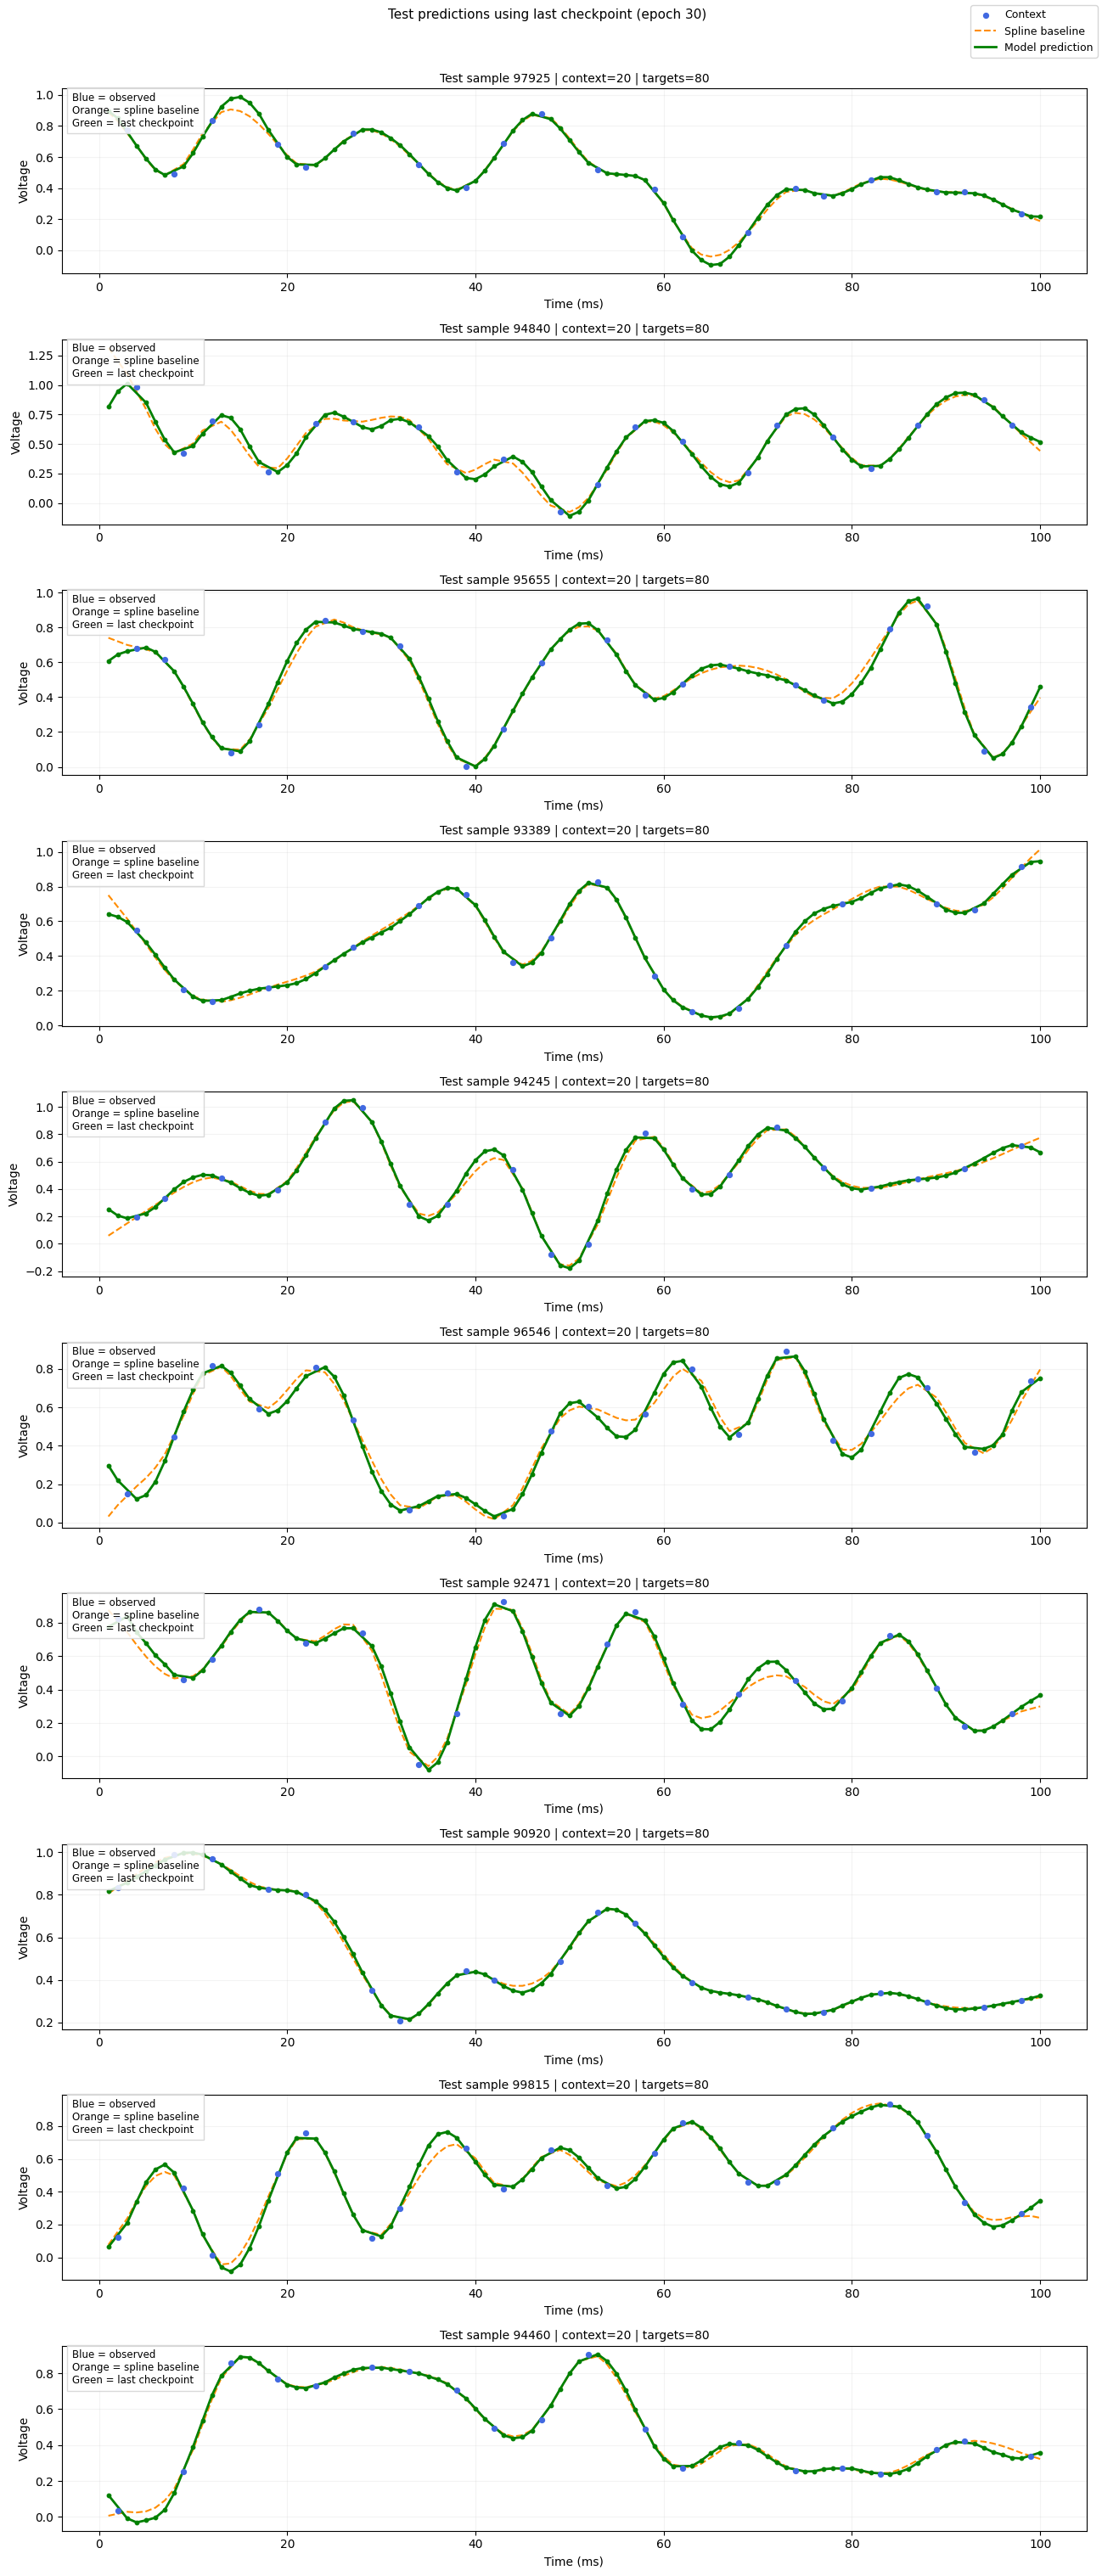

Saved figure: /Users/aman/Desktop/Spectral Bridge/artifacts/test_predictions.png

Submission saved: /Users/aman/Desktop/Spectral Bridge/submission.csv
Rows: 800,000
 Sample_ID  Time_ms  Predicted_Value
     90000      1.0         0.489474
     90000      2.0         0.418705
     90000      3.0         0.335386
     90000      5.0         0.231076
     90000      6.0         0.214690
     90000      8.0         0.255267
     90000      9.0         0.284114
     90000     10.0         0.312173
     90000     11.0         0.326116
     90000     13.0         0.303876


In [12]:
if "torch" not in globals():
    import torch
    import torch.nn as nn

if "ResidualSplineNet" in globals() and Path("last_residual_spline_net.pt").exists():
    device = get_torch_device()
    try:
        checkpoint = torch.load(Path("last_residual_spline_net.pt"), map_location=device, weights_only=False)
    except TypeError:
        checkpoint = torch.load(Path("last_residual_spline_net.pt"), map_location=device)

    checkpoint_cfg = checkpoint.get("model_cfg", RESIDUAL_MODEL_CFG)
    model = ResidualSplineNet(
        hidden_channels=int(checkpoint_cfg["hidden_channels"]),
        num_blocks=int(checkpoint_cfg["num_blocks"]),
        dropout=float(checkpoint_cfg["dropout"]),
    ).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    tolerance = float(checkpoint_cfg.get("accuracy_tolerance", 0.05))
    model_source = f"last checkpoint (epoch {checkpoint.get('epoch', '?')})"
    print(f"Using {model_source}.")
    if "last_val_metrics" in checkpoint:
        print(f"Val MSE:        {checkpoint['last_val_metrics']['mse']:.6f}")
        print(f"Val MAE:        {checkpoint['last_val_metrics']['mae']:.6f}")
        print(f"Val Acc@{tolerance:.2f}:  {checkpoint['last_val_metrics']['accuracy']:.2%}")
    if "baseline_val_stats" in checkpoint:
        print(f"Spline MSE:     {checkpoint['baseline_val_stats']['mse']:.6f}")
        print(f"Spline Acc@{tolerance:.2f}: {checkpoint['baseline_val_stats']['accuracy']:.2%}")
elif "TRAINING_STATE" in globals() and "model" in TRAINING_STATE:
    model = TRAINING_STATE["model"]
    device = TRAINING_STATE["device"]
    checkpoint = None
    tolerance = float(TRAINING_STATE["model_cfg"].get("accuracy_tolerance", 0.05))
    model.eval()
    model_source = "most recently trained in-memory model"
    print(f"Using {model_source}.")
    print(f"Val MSE:        {TRAINING_STATE['last_val_metrics']['mse']:.6f}")
    print(f"Val MAE:        {TRAINING_STATE['last_val_metrics']['mae']:.6f}")
    print(f"Val Acc@{tolerance:.2f}:  {TRAINING_STATE['last_val_metrics']['accuracy']:.2%}")
    print(f"Spline MSE:     {TRAINING_STATE['baseline_val_stats']['mse']:.6f}")
    print(f"Spline Acc@{tolerance:.2f}: {TRAINING_STATE['baseline_val_stats']['accuracy']:.2%}")
else:
    model = None
    device = None
    checkpoint = None
    tolerance = 0.05
    model_source = "edge-aware cubic spline fallback"
    print("No freshly trained model found in memory.")
    print("Falling back to edge-aware cubic spline inference for this run.")


def run_trained_model_inference(
    model: nn.Module,
    prepared_records: Sequence[Dict[str, np.ndarray]],
    device: torch.device,
) -> pd.DataFrame:
    rows_sid: List[int] = []
    rows_time: List[float] = []
    rows_pred: List[float] = []

    model.eval()
    for rec in tqdm(prepared_records, desc="Model inference", disable=TQDM_DISABLED):
        out = predict_one_trained_record(model, rec, device)
        rows_sid.extend([out["sample_id"]] * len(out["time_target"]))
        rows_time.extend(out["time_target"].tolist())
        rows_pred.extend(out["y_pred"].tolist())

    return (
        pd.DataFrame(
            {
                "Sample_ID": np.array(rows_sid, dtype=np.int32),
                "Time_ms": np.array(rows_time, dtype=np.float32),
                "Predicted_Value": np.array(rows_pred, dtype=np.float32),
            }
        )
        .sort_values(["Sample_ID", "Time_ms"], kind="mergesort")
        .reset_index(drop=True)
    )


def plot_trained_test_samples(
    model: nn.Module,
    prepared_records: Sequence[Dict[str, np.ndarray]],
    device: torch.device,
    cfg: BridgeRunConfig,
    model_source: str,
    n: int = 10,
    seed: int = 42,
) -> None:
    n = min(n, len(prepared_records))
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(prepared_records), size=n, replace=False)

    fig, axes = plt.subplots(n, 1, figsize=(13, 3.0 * n), squeeze=False)
    for ax, i in zip(axes.ravel(), idx):
        out = predict_one_trained_record(model, prepared_records[i], device)
        order = np.argsort(out["time_target"])

        ax.scatter(out["time_context"], out["y_context"], s=18, c="royalblue", label="Context", zorder=3)
        ax.plot(out["time_target"][order], out["y_baseline"][order], c="darkorange", lw=1.5, ls="--", label="Spline baseline", zorder=1)
        ax.plot(out["time_target"][order], out["y_pred"][order], c="green", lw=2.0, label="Model prediction", zorder=2)
        ax.scatter(out["time_target"][order], out["y_pred"][order], s=10, c="green", zorder=2)

        ax.set_title(
            f"Test sample {out['sample_id']} | context={len(out['time_context'])} | targets={len(out['time_target'])}",
            fontsize=10,
        )
        ax.set_xlabel("Time (ms)")
        ax.set_ylabel("Voltage")
        ax.grid(alpha=0.15)
        ax.text(
            0.01,
            0.98,
            "Blue = observed\nOrange = spline baseline\nGreen = last checkpoint",
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=8.5,
            bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "lightgray"},
        )

    handles, labels = axes.ravel()[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=9)
    fig.suptitle(f"Test predictions using {model_source}", fontsize=11, y=1.01)
    fig.tight_layout()
    finalize_figure(fig, "test_predictions.png", cfg)


test_csv = find_test_csv(CFG.test_csv_candidates)
if test_csv is not None:
    print(f"\nTest file found: {test_csv}")
    test_df = load_dataframe(test_csv, is_train=False)
    if "Value" not in test_df.columns:
        test_df["Value"] = np.nan
    infer_records = build_sample_records(test_df)
else:
    print("\nNo test CSV found. Running sanity inference on training records instead.")
    _, _, fallback_val_records = get_split_cache(CFG)
    infer_records = fallback_val_records

if model is not None:
    prepared_test_records = [prepare_residual_record(record) for record in infer_records]
    sub = run_trained_model_inference(model, prepared_test_records, device)
    plot_trained_test_samples(
        model,
        prepared_test_records,
        device=device,
        cfg=CFG,
        model_source=model_source,
        n=min(CFG.n_test_plots, len(prepared_test_records)),
        seed=CFG.seed + 202,
    )
else:
    sub = run_inference(infer_records, edge_aware_cubic_predict)
    plot_holdout_samples(
        infer_records,
        predictor=edge_aware_cubic_predict,
        filename="test_predictions.png",
        title="Test predictions using edge-aware cubic spline",
        cfg=CFG,
        show_truth=False,
        n=min(CFG.n_test_plots, len(infer_records)),
        seed=CFG.seed + 202,
    )

sub.to_csv(CFG.submission_path, index=False)
print(f"\nSubmission saved: {CFG.submission_path.resolve()}")
print(f"Rows: {len(sub):,}")
print(sub.head(10).to_string(index=False))
